In [ ]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch
import torchaudio

import numpy as np

import soundfile as sf

from demucs.api import Separator

import librosa
import librosa.display
import noisereduce as nr

import matplotlib.pyplot as plt

from pathlib import Path

from silero_vad import load_silero_vad, get_speech_timestamps

In [ ]:
device = "cuda" if torch.cuda.is_available () else "cpu"

#PROCESSADOR = AutoProcessor.from_pretrained (r"C:\Users\Admin\Desktop\models\ASR Models\Whisper\WhisperLv3-PT-All 4Bit")
#MODELO = AutoModelForSpeechSeq2Seq.from_pretrained (r"C:\Users\Admin\Desktop\models\ASR Models\Whisper\WhisperLv3-PT-All 4Bit", device_map = device, dtype = torch.float16)

DEMUCS_SEPARATOR = Separator (model = "htdemucs")
VAD = load_silero_vad ()

<hr>

In [ ]:
PASTA = Path (r"C:\Users\Admin\Desktop\audio files")

for idx, FILE in enumerate (PASTA.iterdir()):

    WAV, SR = librosa.load (FILE, sr = 44100, mono = False)

    ##########################################
    ########### Time Domain Signal ###########
    ##########################################

    plt.figure (figsize = (22, 5.5))
    librosa.display.waveshow (WAV, sr = SR)
    plt.xlabel ("Tempo (s)")
    plt.ylabel ("Amplitude")
    plt.title ("Forma de Onda")
    plt.savefig (f"Time Domain Signal{idx}.png")

    ##########################################
    ########### Mel Espectrograma ############
    ##########################################

    MEL = librosa.feature.melspectrogram (y = WAV, sr = SR, n_mels = 80)
    Decibeis = librosa.amplitude_to_db (MEL, ref = np.max)

    plt.figure (figsize = (22, 5.5))
    librosa.display.specshow (Decibeis, sr = SR, x_axis = "time", y_axis = "mel")
    plt.colorbar (format = "%+2.0f dB")
    plt.title ("Mel - Espectrograma")
    plt.savefig (f"Mel - Espectrograma{idx}.png")

    ##########################################
    ########### Pré Processamento ############
    ##########################################

    WAV = torch.from_numpy (WAV)

    WAV = WAV.unsqueeze (0)  
    WAV = WAV.repeat (2, 1)   

    ORIGINAL, SEPARADO = DEMUCS_SEPARATOR.separate_tensor (WAV, sr = SR)

    VOZES = SEPARADO ["vocals"]
    VOZES = torchaudio.functional.resample (VOZES, orig_freq = SR, new_freq = 16000)
    VOZES = VOZES.mean (dim = 0)

    VOZES = VOZES / torch.max (torch.abs (VOZES))

    GANHO_DB = 10
    GANHO = 10 ** (GANHO_DB / 20)
    VOZES = VOZES * GANHO

    VOZES = VOZES.numpy ()

    ##########################################
    ########### Time Domain Signal ###########
    ##########################################

    plt.figure (figsize = (22, 5.5))
    librosa.display.waveshow (VOZES, sr = SR)
    plt.xlabel ("Tempo (s)")
    plt.ylabel ("Amplitude")
    plt.title ("Forma de Onda")
    plt.savefig (f"Time Domain Signal - Áudio Final{idx}.png")

    ##########################################
    ########### Mel Espectrograma ############
    ##########################################

    MEL = librosa.feature.melspectrogram (y = VOZES, sr = SR, n_mels = 80)
    Decibeis = librosa.amplitude_to_db (MEL, ref = np.max)

    plt.figure (figsize = (22, 5.5))
    librosa.display.specshow (Decibeis, sr = 16000, x_axis = "time", y_axis = "mel")
    plt.colorbar (format = "%+2.0f dB")
    plt.title ("Mel - Espectrograma")
    plt.savefig (f"Mel - Espectrograma - Áudio Final{idx}.png")

    ### Save
    sf.write (rf"C:\Users\Admin\Desktop\audio files\PPV2\change\change{idx}.wav", VOZES, samplerate = 16000)

<hr>

LibsndfileError: Error opening 'C:\\Users\\Admin\\Desktop\\audio files\\PPV2\\change\\change0.0.wav': System error.

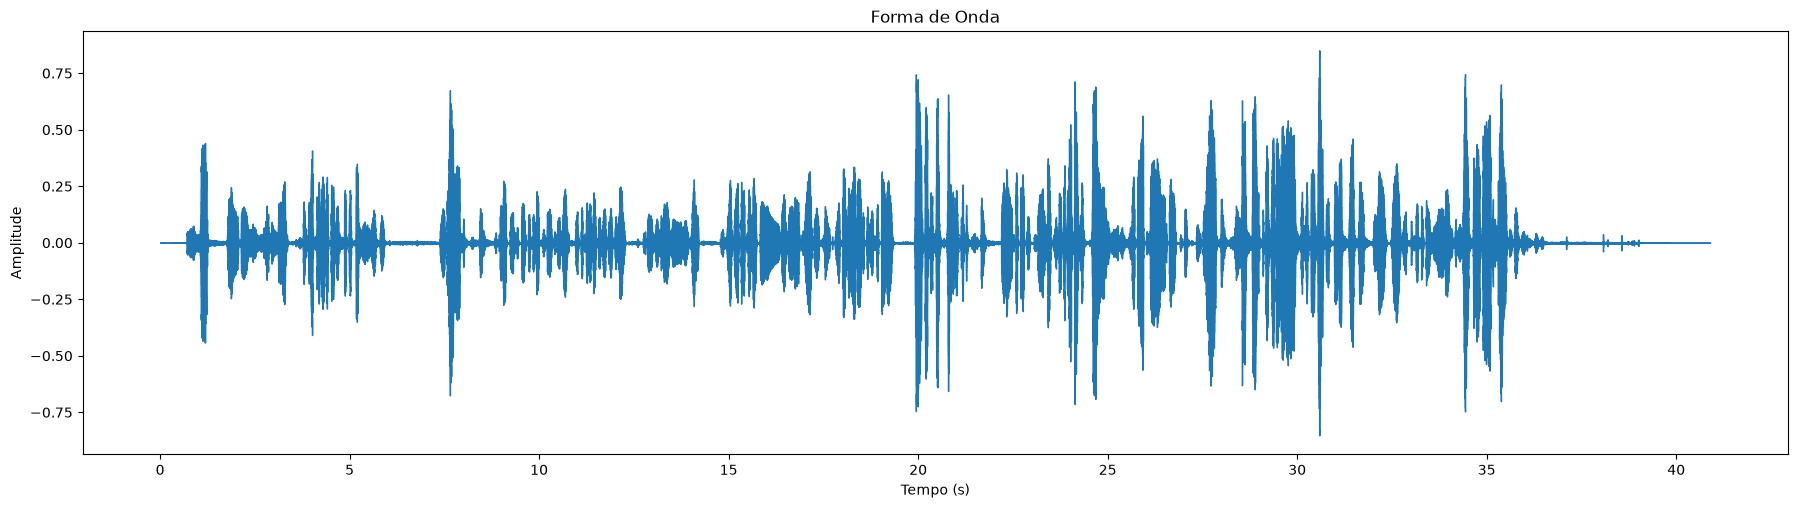

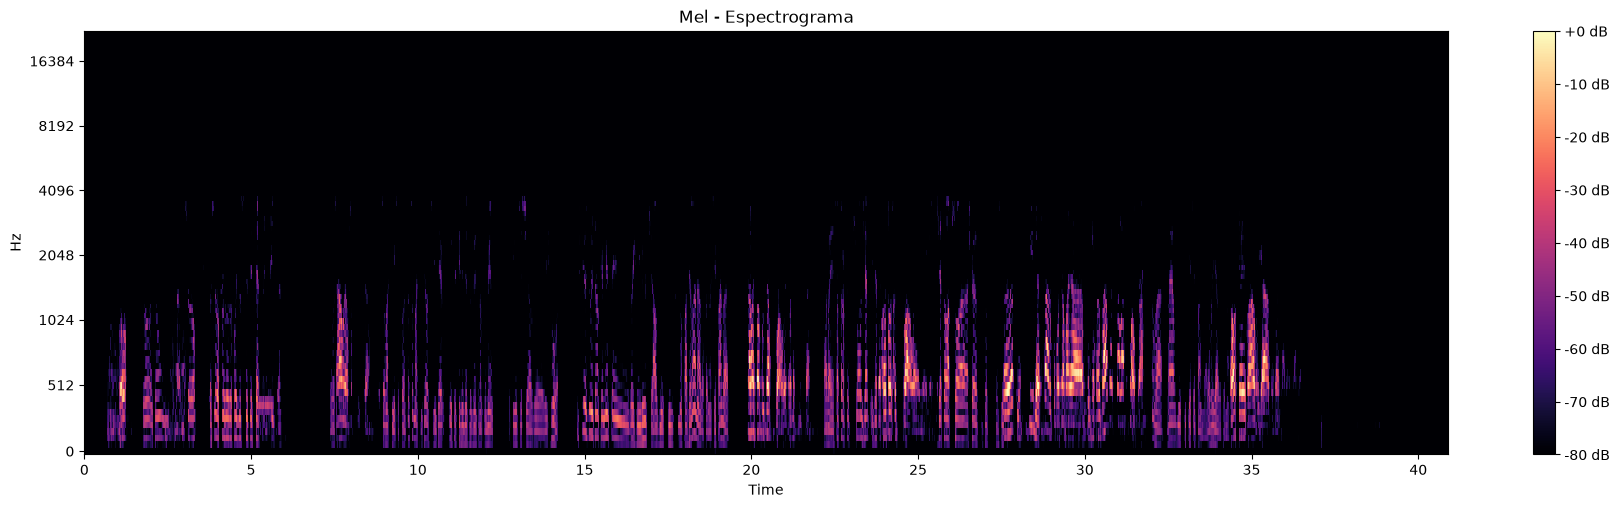

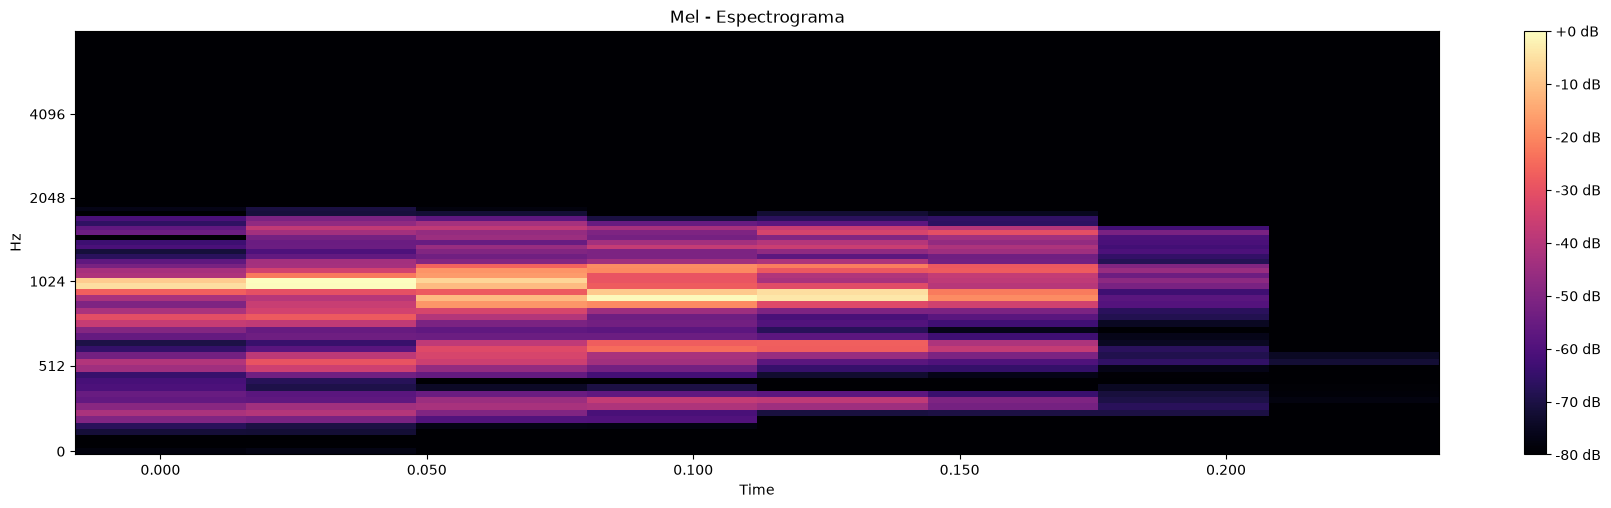

In [8]:
PASTA = Path (r"C:\Users\Admin\Desktop\audio files")

for idx, FILE in enumerate (PASTA.iterdir()):

    WAV, SR = librosa.load (FILE, sr = 44100, mono = False)

    ##########################################
    ########### Time Domain Signal ###########
    ##########################################

    plt.figure (figsize = (22, 5.5))
    librosa.display.waveshow (WAV, sr = SR)
    plt.xlabel ("Tempo (s)")
    plt.ylabel ("Amplitude")
    plt.title ("Forma de Onda")
    plt.savefig (f"Time Domain Signal{idx}.png")

    ##########################################
    ########### Mel Espectrograma ############
    ##########################################

    MEL = librosa.feature.melspectrogram (y = WAV, sr = SR, n_mels = 80)
    Decibeis = librosa.amplitude_to_db (MEL, ref = np.max)

    plt.figure (figsize = (22, 5.5))
    librosa.display.specshow (Decibeis, sr = SR, x_axis = "time", y_axis = "mel")
    plt.colorbar (format = "%+2.0f dB")
    plt.title ("Mel - Espectrograma")
    plt.savefig (f"Mel - Espectrograma{idx}.png")

    ##########################################
    ########### Pré Processamento ############
    ##########################################

    WAV_CUT = get_speech_timestamps (WAV, VAD)

    for idx2, EXCERTOS in enumerate (WAV_CUT):

        WAV2 = WAV [EXCERTOS["start"] : EXCERTOS["end"]]
        WAV2 = torch.from_numpy (WAV2)

        WAV2 = WAV2.unsqueeze (0)
        WAV2 = WAV2.repeat (2, 1)

        ORIGINAL, SEPARADO = DEMUCS_SEPARATOR.separate_tensor (WAV2, sr = SR)

        VOZES = SEPARADO ["vocals"]

        VOZES = torchaudio.functional.resample (VOZES, orig_freq = SR, new_freq = 16000)
        VOZES = VOZES.mean (dim = 0)
        
        VOZES = VOZES / torch.max (torch.abs (VOZES))
        
        GANHO = 10 ** (6 / 20)
        VOZES = VOZES * GANHO
        
        VOZES = VOZES.numpy ()

        ##########################################
        ########### Mel Espectrograma ############
        ##########################################
        
        MEL = librosa.feature.melspectrogram (y = VOZES, sr = SR, n_mels = 80)
        Decibeis = librosa.amplitude_to_db (MEL, ref = np.max)
        
        plt.figure (figsize = (22, 5.5))
        librosa.display.specshow (Decibeis, sr = 16000, x_axis = "time", y_axis = "mel")
        plt.colorbar (format = "%+2.0f dB")
        plt.title ("Mel - Espectrograma")
        plt.savefig (f"Mel - Espectrograma - Áudio Final{idx}.png")
        
        ### Save
        sf.write (rf"C:\Users\Admin\Desktop\audio files\PPV2\change\change{idx}.{idx2}.wav", VOZES, samplerate = 16000)
